<a href="https://colab.research.google.com/github/Raji-317/EDA/blob/main/Outlier_Treatment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as st

In [ ]:
df=pd.read_csv('/WA_Fn-UseC_-Telco-Customer-Churn (1).csv')

FileNotFoundError: [Errno 2] No such file or directory: '/WA_Fn-UseC_-Telco-Customer-Churn (1).csv'

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.isnull().sum()

NameError: name 'df' is not defined

In [ ]:
type(df)

pandas.core.frame.DataFrame

In [ ]:
#Function for detecting the outliers on onedimensional datasets
def find_anomalies(data):
  anamolies=[]
  rand_data_std=st.stdev(data)
  rand_data_mean=st.mean(data)
  anamoly_cut_off=rand_data_std*3

  lower_limit=rand_data_mean-anamoly_cut_off
  upper_limit=rand_data_mean+anamoly_cut_off
  print(lower_limit,upper_limit)

  for outlier in data:
    if outlier>upper_limit or outlier<lower_limit:
      anamolies.append(outlier)
  return anamolies

In [ ]:
df.tenure

,tenure
0,1
1,34
2,2
3,45
4,2
...,...
7038,24
7039,72
7040,11
7041,4


In [ ]:
list1=find_anomalies(df['tenure'])

-41.30729441104115 106.04959172752561


In [ ]:
len(list1)

0

In [ ]:
list2=find_anomalies(df['MonthlyCharges'])

-25.508448832436287 155.03183375363466


In [ ]:
len(list2)

0

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
list3=find_anomalies(df['TotalCharges'].dropna())

-4517.013644807569 9083.6145264913


In [ ]:
len(list3)

0

<Axes: xlabel='tenure', ylabel='Density'>

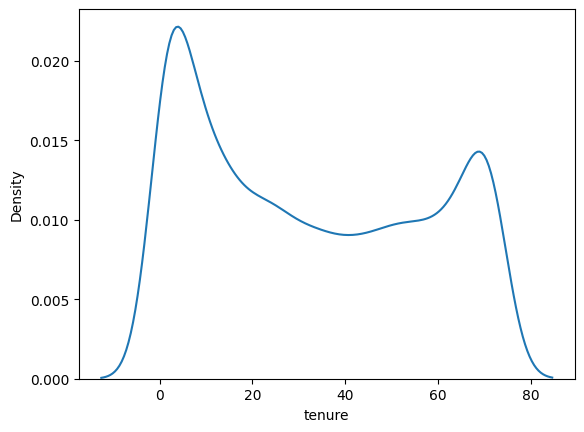

In [ ]:
sns.kdeplot(df['tenure'])

<Axes: >

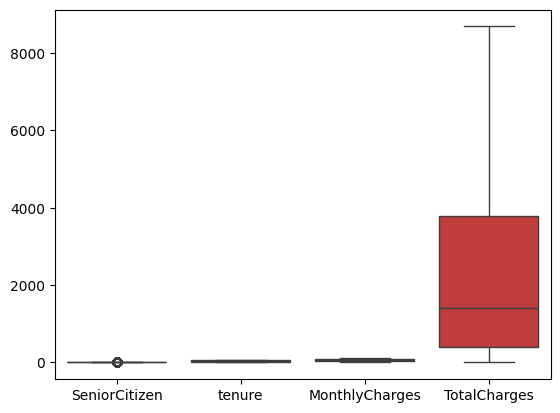

In [ ]:
sns.boxplot(data=df)

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000
